In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [50]:
# reading the data 

df = pd.read_csv(r"C:\Users\sujay\OneDrive\Desktop\data_analysis\0_dataset\height-weight.csv")

In [51]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


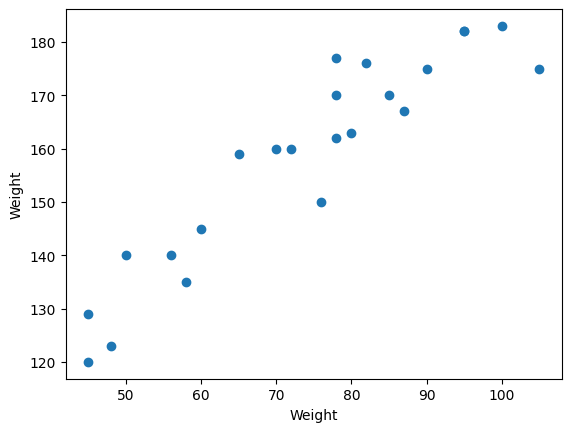

In [52]:
plt.scatter(df.Weight, df.Height)
plt.xlabel("Weight")
plt.ylabel("Weight")
plt.show()

In [53]:
#divide the data into x, y
x = df[["Weight"]] #independent feature
y = df["Height"] # dependent feature

In [54]:
x

,Weight
0,45
1,58
2,48
3,60
4,70
5,78
6,80
7,90
8,95
9,78


In [55]:
y

0     120
1     135
2     123
3     145
4     160
5     162
6     163
7     175
8     182
9     170
10    176
11    182
12    175
13    183
14    170
15    177
16    140
17    159
18    150
19    167
20    129
21    140
22    160
Name: Height, dtype: int64

In [56]:
# train test split
from sklearn.model_selection import train_test_split


In [57]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.25, random_state=1)

In [58]:
x_test

,Weight
20,45
17,65
3,60
13,100
19,87
16,50


In [59]:
x_train

,Weight
10,82
4,70
2,48
18,76
6,80
7,90
1,58
14,85
0,45
15,78


In [60]:
y_test

20    129
17    159
3     145
13    183
19    167
16    140
Name: Height, dtype: int64

In [61]:
y_train

10    176
4     160
2     123
18    150
6     163
7     175
1     135
14    170
0     120
15    177
22    160
21    140
9     170
8     182
12    175
11    182
5     162
Name: Height, dtype: int64

In [62]:
x_train.shape, x_test.shape, y_test.shape, y_train.shape

((17, 1), (6, 1), (6,), (17,))

In [63]:
#scaling > standardization >> fit_transfrom > train, transfrom > test.


In [64]:
from sklearn.preprocessing import StandardScaler

In [65]:
scaler = StandardScaler()

In [66]:
x_train

,Weight
10,82
4,70
2,48
18,76
6,80
7,90
1,58
14,85
0,45
15,78


In [67]:
# Always profrom scaling the data after train test split 
X_train = scaler.fit_transform(x_train) # for train data use fit_transfrom
X_test = scaler.transform(x_test) # for test data only transfrom as it is representative of unknown data 

In [68]:
X_train

array([[ 0.37554243],
       [-0.36825034],
       [-1.73187043],
       [ 0.00364604],
       [ 0.25157697],
       [ 0.87140428],
       [-1.11204312],
       [ 0.56149062],
       [-1.91781863],
       [ 0.12761151],
       [-0.24428488],
       [-1.23600858],
       [ 0.12761151],
       [ 1.18131794],
       [ 1.80114525],
       [ 1.18131794],
       [ 0.12761151]])

In [69]:
X_test

array([[-1.91781863],
       [-0.678164  ],
       [-0.98807766],
       [ 1.49123159],
       [ 0.68545609],
       [-1.60790497]])

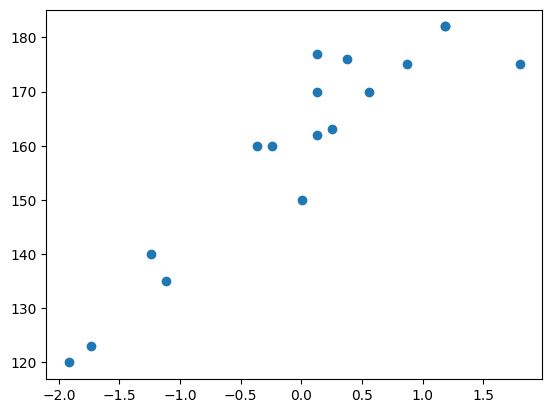

In [70]:
plt.scatter(X_train, y_train)

In [71]:
# moddel training 

from sklearn.linear_model import LinearRegression

#linear regression parameters:
#fit_intercept >> the best fit line will have intercept, by default it is true.
#copy_x >> copy the orizinal x_train and then build the model, dont modify the orizinal data, by default >>it is true
#n_jobs >> processor you want to use 
#positive >> you want all of your coefficient to be positive 

# after building the model , you have attributes of the mode
# coef
#intercept

In [72]:
regressor = LinearRegression()

In [73]:
regressor

LinearRegression()

In [74]:
#training of the model
regressor.fit(X_train, y_train)

LinearRegression()

In [75]:
print("the slope or coef of model is :", regressor.coef_)
print("the intercept of the model is :",regressor.intercept_)

the slope or coef of model is : [17.7307072]
the intercept of the model is : 160.0


In [76]:
# prediction of train data
# predicted height output = intercept + coef_(weights), y_pred_train = 160.0 + 17.74 * (X_train)

#prediction of test data
# predicted height output = intercept + coef_(weights), y_pred_test = 160.0 + 17.74 * (X_test)

In [77]:
# pradiction of train data
regressor.predict(X_train)

array([166.65863288, 153.47066096, 129.29271243, 160.06464692,
       164.46063756, 175.45061417, 140.28268904, 169.95562586,
       125.99571945, 162.26264224, 155.66865628, 138.08469371,
       162.26264224, 180.94560247, 191.93557907, 180.94560247,
       162.26264224])

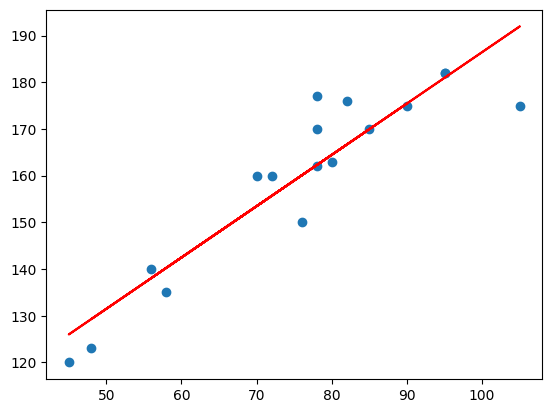

In [78]:
plt.scatter(x_train, y_train)
plt.plot(x_train, regressor.predict(X_train), 'r')

In [79]:
y_pred_test = regressor.predict(X_test)

In [80]:
y_pred_test, y_test

(array([125.99571945, 147.97567266, 142.48068436, 186.44059077,
        172.15362118, 131.49070775]),
 20    129
 17    159
 3     145
 13    183
 19    167
 16    140
 Name: Height, dtype: int64)

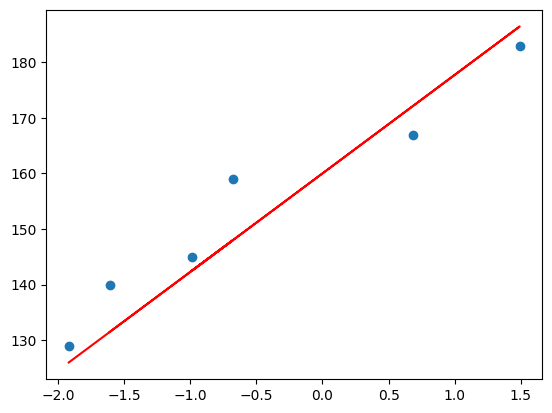

In [81]:
plt.scatter(X_test, y_test)
plt.plot(X_test, regressor.predict(X_test), 'r')

In [82]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [83]:
mse = mean_squared_error(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mse)

print(mse, mae, rmse)

41.285662830455514 5.608571289304838 6.425392037102134


In [84]:
#Rsquare = 1-ssr/sst

In [85]:
from sklearn.metrics import r2_score

In [86]:
Rscore = r2_score(y_test, y_pred_test)

In [87]:
# adjusted r square
# R2 = 1 - [(1-R2)*(n-1)/(n-r-1)] #n is no of obs, R is no predictor variables

In [88]:
1-(1-Rscore)*(len(y_test)-1)/(len(y_test) - X_test.shape[1] -1)
#adjusted rsquare will be always lesser then rsquare

0.8401295217820757

In [89]:
# to get no of columns
X_test.shape[1]

1

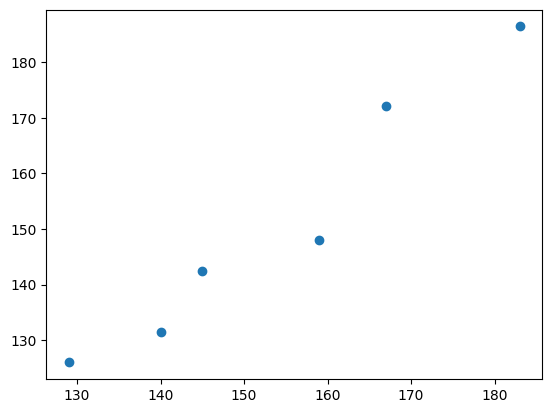

In [93]:
# assumption 
# X-y should have linear relationship
# observation should have no relation
# error should have constent variance 
# error should be normally distributed 

plt.scatter(y_test, y_pred_test) 

In [96]:
error = y_test - y_pred_test
error

20     3.004281
17    11.024327
3      2.519316
13    -3.440591
19    -5.153621
16     8.509292
Name: Height, dtype: float64

In [97]:
import seaborn as sns

C:\Users\sujay\AppData\Local\Temp\ipykernel_11220\3497407678.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error, kde=True)


<Axes: xlabel='Height', ylabel='Density'>

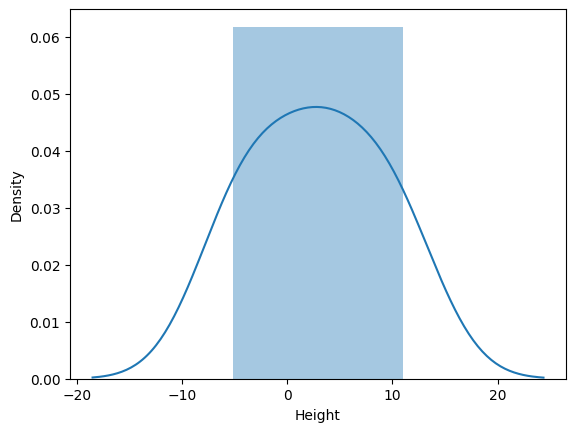

In [98]:
sns.distplot(error, kde=True)

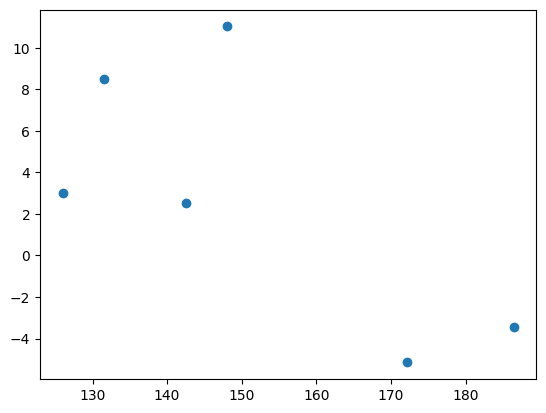

In [99]:
# error should have constent variance 

plt.scatter(y_pred_test, error)